In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p157.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p169.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p150.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p159.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p146.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p167.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p153.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p136.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p138.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/petunia/p152.jpeg
/kaggle/input/datasets/bibihazaratunnesa/flower-species-data

In [3]:
dataset_path = "/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower"

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

2026-03-16 16:45:17.759567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773679518.209722      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773679518.322880      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773679519.448506      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773679519.448546      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773679519.448549      55 computation_placer.cc:177] computation placer alr

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    dataset_path + "/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    dataset_path + "/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 820 images belonging to 6 classes.
Found 212 images belonging to 6 classes.


In [6]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773679556.978346      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773679556.984128      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773679562.883141     140 service.cc:152] XLA service 0x780d6c005ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773679562.883178     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773679562.883182     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773679563.348968     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-16 16:46:06.483676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 16:46:06.631533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.1094 - loss: 3.5606

I0000 00:00:1773679569.765214     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.2081 - loss: 2.5793

2026-03-16 16:46:31.347755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 16:46:31.493745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2139 - loss: 2.5326 - val_accuracy: 0.3679 - val_loss: 1.4563
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 774ms/step - accuracy: 0.4275 - loss: 1.4883 - val_accuracy: 0.4387 - val_loss: 1.4086
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 781ms/step - accuracy: 0.4631 - loss: 1.3278 - val_accuracy: 0.5377 - val_loss: 1.2335
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 771ms/step - accuracy: 0.5681 - loss: 1.1544 - val_accuracy: 0.4858 - val_loss: 1.2552
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 775ms/step - accuracy: 0.6083 - loss: 1.0211 - val_accuracy: 0.5519 - val_loss: 1.2154
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 789ms/step - accuracy: 0.6173 - loss: 1.0726 - val_accuracy: 0.5755 - val_loss: 1.3108
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 773ms/step - accuracy: 0.6579 - loss: 0.9423 - val_accuracy: 0.5425 - val_loss: 1.2272
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 778ms/step - accuracy: 0.6945 - loss: 0.8331 - val_accuracy: 0.5283 -

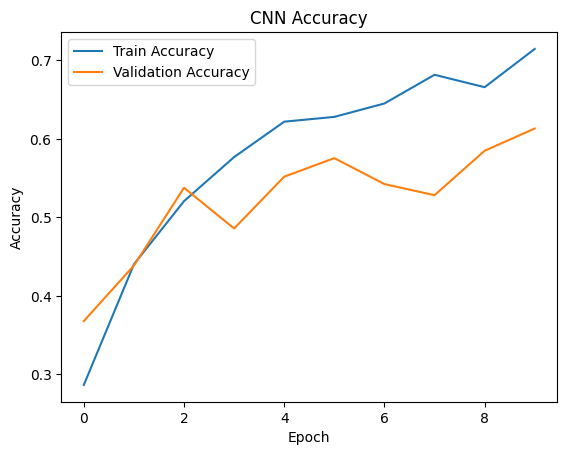

In [8]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

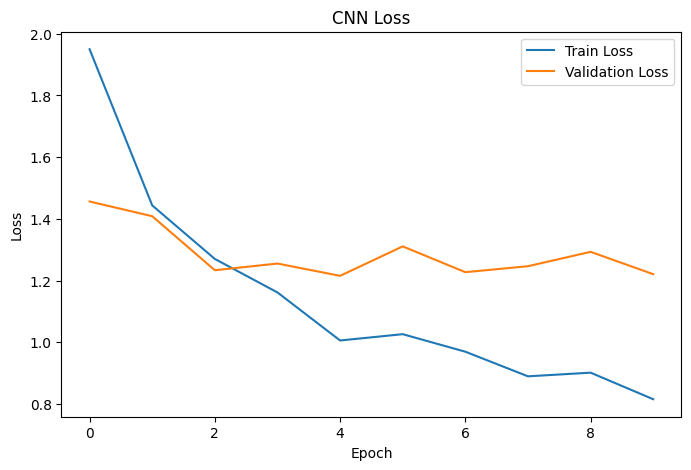

In [9]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10


2026-03-16 16:49:59.204010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 16:49:59.340277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


10/26 ━━━━━━━━━━━━━━━━━━━━ 9s 611ms/step - accuracy: 0.2722 - loss: 2.0257 

2026-03-16 16:50:15.280443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 16:50:15.420390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


26/26 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.3843 - loss: 1.6979 - val_accuracy: 0.7358 - val_loss: 0.8032
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 805ms/step - accuracy: 0.7120 - loss: 0.8104 - val_accuracy: 0.8019 - val_loss: 0.6212
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 770ms/step - accuracy: 0.8052 - loss: 0.5368 - val_accuracy: 0.8396 - val_loss: 0.5236
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 781ms/step - accuracy: 0.8319 - loss: 0.4703 - val_accuracy: 0.8538 - val_loss: 0.4668
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 777ms/step - accuracy: 0.8495 - loss: 0.4405 - val_accuracy: 0.8349 - val_loss: 0.4471
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 765ms/step - accuracy: 0.8732 - loss: 0.3632 - val_accuracy: 0.8160 - val_loss: 0.4586
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 771ms/step - accuracy: 0.9032 - loss: 0.3287 - val_accuracy: 0.8632 - val_loss: 0.4033
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 794ms/step - accuracy: 0.9028 - loss: 0.3069 - val_accuracy: 0.8443 -

TypeError: 'History' object is not subscriptable

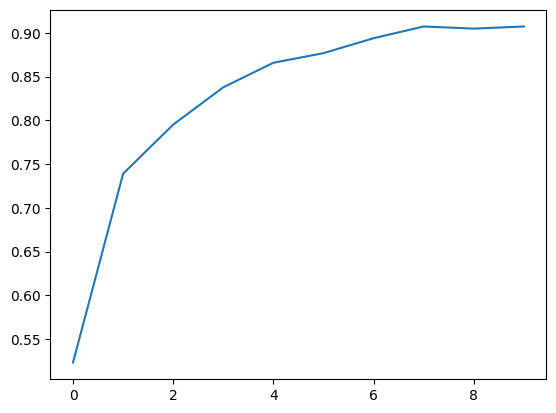

In [14]:
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNetV2')

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [ ]:
y_pred = mobilenet_model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")

plt.show()

In [ ]:
y_pred_cnn = cnn_model.predict(test_data)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

In [ ]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
img_path = "/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/hibiscus/h119.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = mobilenet_model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Flower:", predicted_class)

In [ ]:
prediction = mobilenet_model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Flower:", predicted_class)